In [1]:
import numpy as np
import pandas as pd

QUESTION 1 – NumPy Operations 

In [13]:
df = pd.read_csv("AI_Practical_Dataset.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,16.893808,392467600,AAPL
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,16.985926,412610800,AAPL
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,16.864458,317209200,AAPL
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,16.971254,258529600,AAPL
...,...,...,...,...,...,...,...,...
25155,2023-12-22,290.309998,292.829987,288.910004,290.359985,287.971252,2833800,CAT
25156,2023-12-26,291.589996,297.089996,291.000000,295.630005,293.197906,2019000,CAT
25157,2023-12-27,295.630005,299.149994,294.730011,298.119995,295.667419,1876500,CAT
25158,2023-12-28,297.100006,299.200012,296.040009,296.880005,294.437622,2267400,CAT


In [7]:
#Q1.1: Convert Volume values into a NumPy array.
volume_array = np.array(df["Volume"])
print("First 5 Volume values:")
print(volume_array[:5])

First 5 Volume values:
[234684800 392467600 412610800 317209200 258529600]


In [12]:
#Q1.2: Calculate the following statistics for Open prices:
open_array = np.array(df["Open"])
#mean 
mean_open = np.mean(open_array)
#std 
std_open = np.std(open_array)
# Maximum
max_open = np.max(open_array)
# Minimum
min_open = np.min(open_array)
print("Mean Opening Price:", mean_open)
print("Standard Deviation:", std_open)
print("Maximum Opening Price:", max_open)
print("Minimum Opening Price:", min_open)

Mean Opening Price: 117.99575606086107
Standard Deviation: 74.12318225902551
Maximum Opening Price: 423.1199951171875
Minimum Opening Price: 14.220000267028809


In [14]:
#Q1.3: Normalize the Close prices using Min-Max normalization
#Normalization Formula 
# nor = (x - x_min) / (x_max - x_min)
# Convert Close to NumPy array
close_array = np.array(df["Close"])
# Find min and max
min_close = np.min(close_array)
max_close = np.max(close_array)
# Apply Min-Max Normalization
normalized_close = (close_array - min_close) / (max_close - min_close)
print("First 5 Normalized Close Prices:")
print(normalized_close[:5])

First 5 Normalized Close Prices:
[0.01320417 0.01214453 0.01240181 0.01206255 0.01236082]


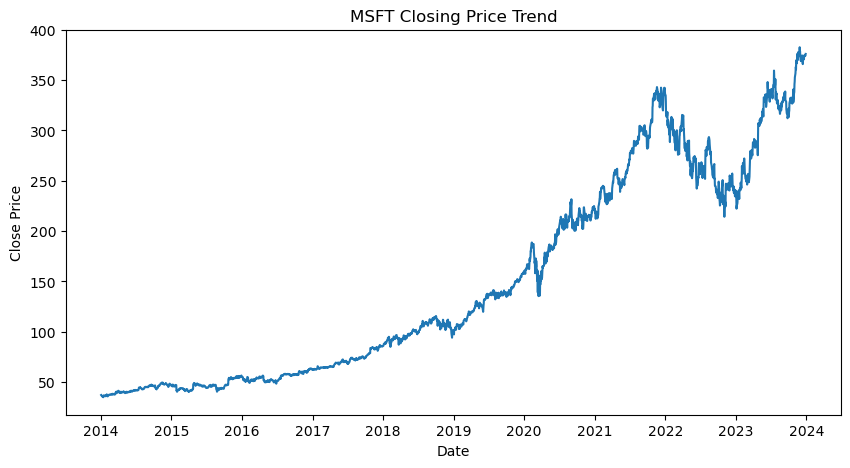

In [15]:
#Q1.4: Plot the closing price trend for MSFT using Matplotlib. 
import matplotlib.pyplot as plt

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Filter data for MSFT
msft_df = df[df["Ticker"] == "MSFT"]

# Plot
plt.figure(figsize=(10,5))
plt.plot(msft_df["Date"], msft_df["Close"])
plt.title("MSFT Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

QUESTION 2 – Data Analysis using Pandas 

In [16]:
# Q2.1: Display first 5 rows and summary statistics of numeric columns.

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Display summary statistics of numeric columns
print("\nSummary Statistics:")
print(df.describe())

First 5 Rows:
        Date       Open       High        Low      Close  Adj Close  \
0 2014-01-02  19.845715  19.893929  19.715000  19.754642  17.273226   
1 2014-01-03  19.745001  19.775000  19.301071  19.320715  16.893808   
2 2014-01-06  19.194643  19.528570  19.057142  19.426071  16.985926   
3 2014-01-07  19.440001  19.498571  19.211430  19.287144  16.864458   
4 2014-01-08  19.243214  19.484285  19.238930  19.409286  16.971254   

      Volume Ticker  
0  234684800   AAPL  
1  392467600   AAPL  
2  412610800   AAPL  
3  317209200   AAPL  
4  258529600   AAPL  

Summary Statistics:
                                Date          Open          High  \
count                          25160  25160.000000  25160.000000   
mean   2018-12-31 00:18:53.227344640    117.995756    119.114468   
min              2014-01-02 00:00:00     14.220000     14.521000   
25%              2016-06-30 18:00:00     61.150002     61.695625   
50%              2019-01-01 00:00:00    101.045002    101.870003  

In [17]:
# Q2.2: Check for missing values in the dataset and fill them with the previous value. 

# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Fill missing values using forward fill (previous value)
df = df.ffill()
print("\nMissing Values After Filling:")
print(df.isnull().sum())

Missing Values in Each Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Missing Values After Filling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64


In [18]:
# Q2.3: Create a new column: Daily Return = (Close − Open) / Open.

# Create Daily Return column
df["Daily_Return"] = (df["Close"] - df["Open"]) / df["Open"]
print("\nFirst 5 Daily Returns:")
print(df["Daily_Return"].head())


First 5 Daily Returns:
0   -0.004589
1   -0.021488
2    0.012057
3   -0.007863
4    0.008630
Name: Daily_Return, dtype: float64


In [19]:
# Q2.4: Calculate the correlation matrix for Open, High, Low, Close.

# Select required columns
selected_columns = df[["Open", "High", "Low", "Close"]]

# Calculate correlation matrix
correlation_matrix = selected_columns.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
           Open      High       Low     Close
Open   1.000000  0.999862  0.999844  0.999692
High   0.999862  1.000000  0.999798  0.999851
Low    0.999844  0.999798  1.000000  0.999855
Close  0.999692  0.999851  0.999855  1.000000


In [20]:
# Q2.5: Identify which feature is most correlated with Close price.

# Get correlation with Close column
corr_with_close = correlation_matrix["Close"]

# Remove Close itself
corr_with_close = corr_with_close.drop("Close")

# Find highest correlation value
most_correlated_feature = corr_with_close.idxmax()
print("\nFeature Most Correlated with Close:")
print(most_correlated_feature)


Feature Most Correlated with Close:
Low


QUESTION 3 – Regression Model (Stock Price Prediction)

In [23]:
# Q3.1: Define independent variables (Open, High, Low, Volume) and dependent variable (Close)

# Define Independent Variables (X)
X = df[["Open", "High", "Low", "Volume"]]

# Define Dependent Variable (y)
y = df["Close"]
print("Independent Variables (X):")
print(X.head())
print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
        Open       High        Low     Volume
0  19.845715  19.893929  19.715000  234684800
1  19.745001  19.775000  19.301071  392467600
2  19.194643  19.528570  19.057142  412610800
3  19.440001  19.498571  19.211430  317209200
4  19.243214  19.484285  19.238930  258529600

Dependent Variable (y):
0    19.754642
1    19.320715
2    19.426071
3    19.287144
4    19.409286
Name: Close, dtype: float64


In [24]:
#Q3.2: Split data into training (80%) and testing (20%) sets.

from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, shuffle=False
)
print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (20128, 4)
Testing Data Size: (5032, 4)


In [25]:
#Q3.3: Train a Linear Regression model on the training data.

from sklearn.linear_model import LinearRegression
# Create model
model = LinearRegression()
# Train model
model.fit(X_train, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [26]:
#Q3.4: Display the model's coefficients and intercept. 
# Intercept
print("Intercept:", model.intercept_)
# Coefficients
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
 print(feature, ":", coef)

Intercept: 0.0016025053674155743
Coefficients:
Open : -0.6021665436262652
High : 0.8050024999023715
Low : 0.7973060861975212
Volume : 7.842891155412394e-11


In [27]:
#Q3.5:Evaluate the model using R² score and Mean Squared Error
from sklearn.metrics import r2_score, mean_squared_error
# Make predictions
predictions = model.predict(X_test)
# Calculate R2 score
r2 = r2_score(y_test, predictions)
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, predictions)
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

R2 Score: 0.9997769004114425
Mean Squared Error: 0.6439309829097486


In [30]:
#Q3.6: Predict Close price for new input: Open=145.5, High=147.2, Low=144.8, Volume=85,000,000.
import pandas as pd

new_input = pd.DataFrame({
    'Open': [145.5],
    'High': [147.2],
    'Low': [144.8],
    'Volume': [85000000]
})

predicted_close = model.predict(new_input)

print("Predicted Close Price:", predicted_close[0])

Predicted Close Price: 146.33932613225807


QUESTION 4 – Model Interpretation

In [ ]:
# Q4.1: What does a regression coefficient represent?
'''A regression coefficient represents how much the dependent variable (Close price) changes when the 
independent variable (Open, High, Low, or Volume) increases by one unit, while keeping other variables 
constant.
📌Simple Explanation:
If the coefficient of Open is 0.8, it means:
• When Open price increases by ₹1,
• The Close price is expected to increase by ₹0.8 (approximately),
• Assuming other variables remain the same.
📌Important Points:
• Positive coefficient → Increase in feature increases Close price.
• Negative coefficient → Increase in feature decreases Close price.
• Larger magnitude → Stronger influence on prediction.'''

In [ ]:
# Q4.2: If R² = 0.85, what does it mean? 
'''If R² = 0.85, it means that:
 The regression model explains 85% of the variation in the Close price.
 Simple Explanation:
• The model is able to predict the Close price with 85% accuracy (fit).
• The remaining 15% variation is due to:
o Market uncertainty
o External factors
o Noise in data
📌Interpretation Scale:
• R² = 1 → Perfect prediction
• R² > 0.8 → Very good model
• R² around 0.5 → Moderate model
• R² close to 0 → Poor model
So, 0.85 means the model is strong but not perfect.'''

In [ ]:
# Q4.3: Why is stock price prediction challenging?
'''Stock price prediction is challenging because stock markets are influenced by many unpredictable factors 
such as:
• Economic conditions
• News events
• Company performance
• Government policies
• Investor emotions
• Global market trends
Stock prices are highly volatile and dynamic, making exact prediction very difficult'''

QUESTION 5 – Basic Forecasting Task 

In [31]:
# Q5.1: Create a 5-day Simple Moving Average column for Close prices. 
import pandas as pd
# Load dataset
df = pd.read_csv("AI_Practical_Dataset.csv")
# Create 5-day Simple Moving Average column
df["SMA_5"] = df["Close"].rolling(window=5).mean()
# Display first 10 rows
print(df[["Date", "Close", "SMA_5"]].head(10))

         Date      Close      SMA_5
0  2014-01-02  19.754642        NaN
1  2014-01-03  19.320715        NaN
2  2014-01-06  19.426071        NaN
3  2014-01-07  19.287144        NaN
4  2014-01-08  19.409286  19.439572
5  2014-01-09  19.161428  19.320929
6  2014-01-10  19.033571  19.263500
7  2014-01-13  19.133215  19.204929
8  2014-01-14  19.513929  19.250286
9  2014-01-15  19.905714  19.349572


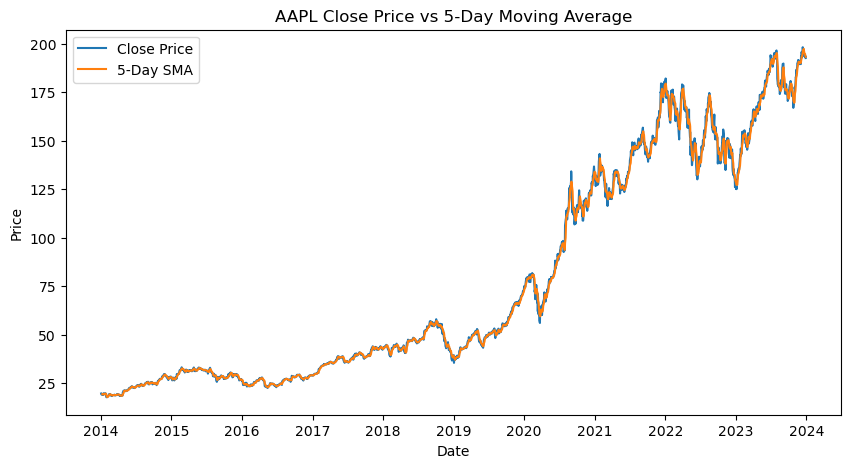

In [32]:
# Q5.2: Plot Close price and 5-day Moving Average together for AAPL using seaborn.
import seaborn as sns
import matplotlib.pyplot as plt
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])
# Filter AAPL data
aapl_df = df[df["Ticker"] == "AAPL"]
# Create plot
plt.figure(figsize=(10,5))
sns.lineplot(x="Date", y="Close", data=aapl_df, label="Close Price")
sns.lineplot(x="Date", y="SMA_5", data=aapl_df, label="5-Day SMA")
plt.title("AAPL Close Price vs 5-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [33]:
# Q5.3: Predict the next day's closing price for AAPL using your regression model.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
# Filter AAPL data
aapl_df = df[df["Ticker"] == "AAPL"]
# Define X and y
X = aapl_df[["Open", "High", "Low", "Volume"]]
y = aapl_df["Close"]
# Split data
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, shuffle=False
)
# Train model
model = LinearRegression()
model.fit(X_train, y_train)
# Take latest available row
latest_row = X.iloc[[-1]]
# Predict next day closing price
next_day_prediction = model.predict(latest_row)
print("Predicted Next Day Close Price for AAPL:", next_day_prediction[0])

Predicted Next Day Close Price for AAPL: 192.57631371761013


In [ ]:
# Q5.4: Write 3 simple business insights from your model.
'''High Correlation Between Open and Close:
The model shows strong correlation between Open and Close price, meaning opening trends strongly 
influence closing price.
 Moving Average Shows Trend Direction:
The 5-day SMA smooths daily fluctuations and helps identify upward or downward market trend.
 Regression Model Provides Good Fit:
If R² is high, the model explains most of the variation in Close price, indicating strong relationship between 
price variables.'''

QUESTION 6 – Data Visualization with Seaborn 

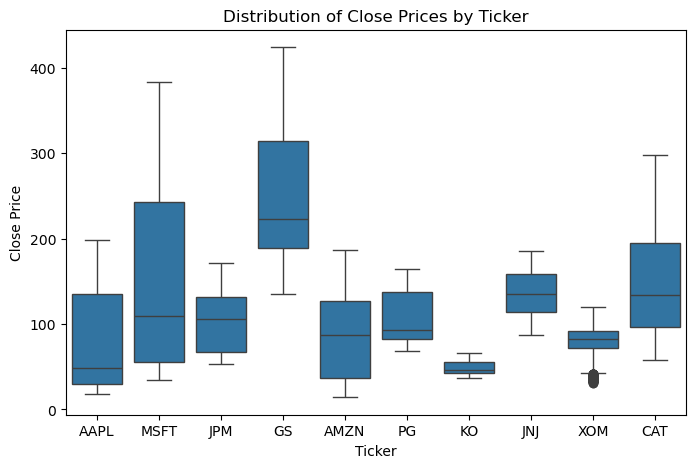

In [34]:
# Q6.1: Create a box plot to show the distribution of Close prices for each ticker.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("AI_Practical_Dataset.csv")
# Create box plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Ticker", y="Close", data=df)
plt.title("Distribution of Close Prices by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Close Price")
plt.show()

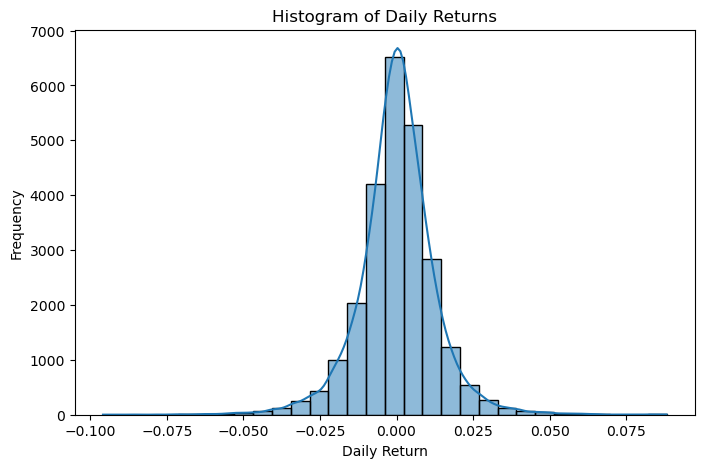

In [36]:
# Q6.2: Create a histogram of Daily Returns.
# First create Daily Return if not created.
# Create Daily Return column
df["Daily_Return"] = (df["Close"] - df["Open"]) / df["Open"]
# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Return"], bins=30, kde=True)
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

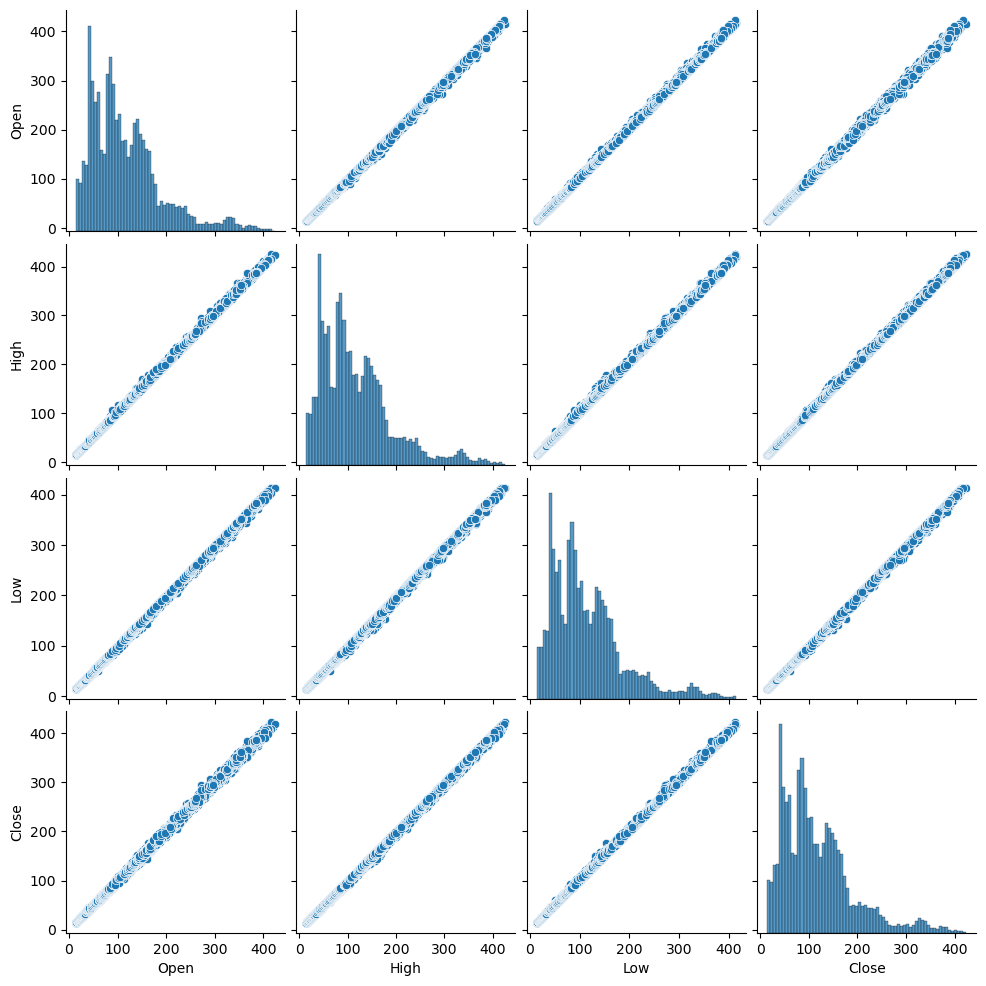

In [37]:
# Q6.3: Create a pair plot of Open, High, Low, Close prices. 
'''Shows:
• Scatter plots between each pair of variables
• Distribution on diagonal'''
# Select required columns
selected_columns = df[["Open", "High", "Low", "Close"]]
# Create pair plot
sns.pairplot(selected_columns)
plt.show()

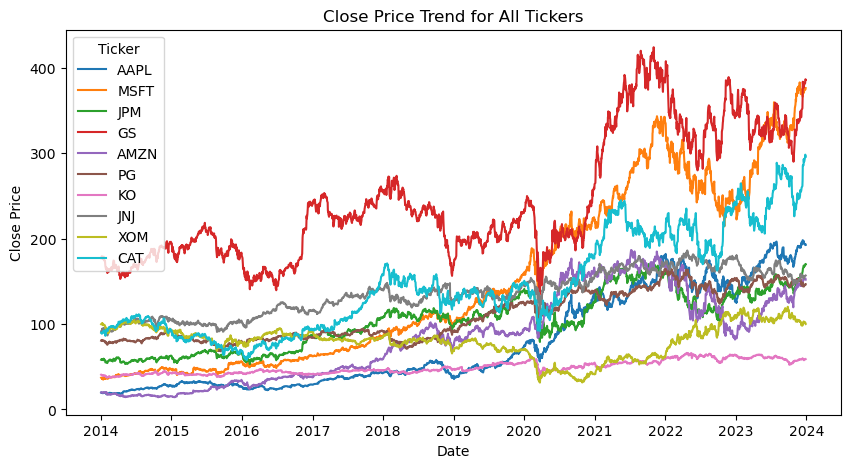

In [38]:
# Q6.4: Create a line plot showing Close price trends for all tickers. 
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])
plt.figure(figsize=(10,5))
# Line plot with hue for different tickers
sns.lineplot(x="Date", y="Close", hue="Ticker", data=df)
plt.title("Close Price Trend for All Tickers")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

QUESTION 7 – Advanced NumPy Operations

In [39]:
# Q7.1: Calculate the 25th, 50th, and 75th percentiles for High prices. 
'''📌What are Percentiles?
• 25th percentile → First Quartile (Q1)
• 50th percentile → Median (Q2)
• 75th percentile → Third Quartile (Q3)'''
import numpy as np
import pandas as pd
# Load dataset
df = pd.read_csv("AI_Practical_Dataset.csv")
# Convert High column to NumPy array
high_array = np.array(df["High"])
# Calculate percentiles
p25 = np.percentile(high_array, 25)
p50 = np.percentile(high_array, 50)
p75 = np.percentile(high_array, 75)
print("25th Percentile:", p25)
print("50th Percentile (Median):", p50)
print("75th Percentile:", p75)

25th Percentile: 61.69562530517578
50th Percentile (Median): 101.87000274658205
75th Percentile: 154.14500045776367


In [40]:
# Q7.2: Calculate daily price range (High - Low) and find its mean, max, and min.
# Calculate Daily Price Range
price_range = df["High"] - df["Low"]
# Convert to NumPy array
range_array = np.array(price_range)
# Calculate statistics
mean_range = np.mean(range_array)
max_range = np.max(range_array)
min_range = np.min(range_array)
print("Mean Daily Range:", mean_range)
print("Maximum Daily Range:", max_range)
print("Minimum Daily Range:", min_range)

Mean Daily Range: 2.2507051616480696
Maximum Daily Range: 25.209991455078125
Minimum Daily Range: 0.11499977111816406


In [41]:
# Q7.3: Normalize the Low prices using Z-score standardization.
# Convert Low to NumPy array
low_array = np.array(df["Low"])
# Calculate mean and std
mean_low = np.mean(low_array)
std_low = np.std(low_array)
# Apply Z-score normalization
low_zscore = (low_array - mean_low) / std_low
print("First 5 Z-score Normalized Low Prices:")
print(low_zscore[:5])

First 5 Z-score Normalized Low Prices:
[-1.32492008 -1.33056526 -1.33389198 -1.3317878  -1.33141275]


In [42]:
# Q7.4: Calculate the logarithm of Volume values.
# Convert Volume to NumPy array
volume_array = np.array(df["Volume"])
# Calculate natural logarithm
log_volume = np.log(volume_array)
print("First 5 Log Volume Values:")
print(log_volume[:5])

First 5 Log Volume Values:
[19.2737539  19.78796454 19.83801533 19.57507205 19.37052075]
